In [4]:
import numpy as np
import pandas as pd
import random
import math
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import KNNImputer
from imblearn.under_sampling import NearMiss 
from imblearn.over_sampling import BorderlineSMOTE
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss
import sys

sys.path.insert(0, "../Modules")

pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)

from utils import *

In [5]:
NUTS0 = 'GR'
NUTS2 = 'Thessaly'

In [6]:
f = open(f"data/{NUTS0}_WNV_{NUTS2}_cases_dates.txt", "r")
print(f.read())

months: 7, 8, 9, 10, 
years: 2010, 2011, 2018, 2019, 2020, 


In [7]:
r_u = 0
near_u = 0
smote = 0
scaler = 'minmax'
years_to_remove = []
path = f'data/{NUTS0}_{NUTS2}_WNV_Dataset_2010_2021.csv'

In [8]:
dataset = read_data(path, exclude_years = years_to_remove)
dataset.head()

,x,y,dt_placement,nuts2,lau1,lau1_id,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,landcover_1990,landcover_2000,landcover_2006,landcover_2012,landcover_2018,mosq_pred,mosq_previous,case
0,22.77356,39.67760,2010-01-01,θεσσαλιας,αγιας,22,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,661.8,10705.0,17.3,45.74874,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.267143,16.284286,8.25,11.242240,5.302469,9.587946,4.419169,16.775915,6.090496,19.523378,8.155853,22.057143,52.814286,0.0,295.000000,295.000000,295.000000,295.000000,295.000000,55,0,0
1,22.69493,39.10844,2010-01-01,θεσσαλιας,αλμυρου,6,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,905.4,16004.0,20.6,45.21648,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.082222,16.254444,11.91,9.896909,4.265526,10.677746,3.618618,17.039068,5.650136,20.541023,7.613520,13.700000,31.211111,0.3,260.444444,260.444444,260.444444,260.444444,260.444444,41,0,0
2,23.91189,39.20320,2010-01-01,θεσσαλιας,αλοννησου,24,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,129.6,3153.0,21.2,45.92025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.640000,17.470000,11.81,12.687143,9.572857,11.814615,7.350000,14.911538,8.634000,17.832609,10.427500,62.200000,98.600000,0.0,323.000000,323.000000,323.000000,323.000000,323.000000,24,0,0
3,21.43052,39.25731,2010-01-01,θεσσαλιας,αργιθεας,0,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,372.9,3515.0,9.3,44.72587,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.565556,0.587778,5.773333,-1.428201,13.292222,2.807245,18.730554,6.231131,47.133333,88.466667,22.1,323.666667,323.666667,320.000000,320.000000,320.000000,94,0,0
4,22.93792,39.41186,2010-01-01,θεσσαλιας,βολου,14,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,385.6,138865.0,374.6,45.60091,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.356667,NaN,12.845119,5.105833,12.089515,3.862547,17.407709,6.368088,21.703833,8.805092,30.066667,48.733333,0.0,252.666667,252.666667,252.666667,252.666667,252.666667,34,0,0


In [9]:
dataset = dataset.query('month >= 6 & month <= 10')
dataset.reset_index(inplace=True, drop=True)

In [10]:
dsc = dataframe_describe(dataset)
dsc.head(15)

,year,non-case,case,total,percentage
0,2010,244,9,253,8.33%
1,2011,227,30,257,8.47%
2,2012,250,0,250,8.23%
3,2013,250,0,250,8.23%
4,2014,250,0,250,8.23%
5,2015,250,0,250,8.23%
6,2016,250,0,250,8.23%
7,2017,250,0,250,8.23%
8,2018,245,7,252,8.30%
9,2019,220,53,273,8.99%


In [11]:
feature_list = dataset.select_dtypes(exclude=['object']).drop(columns = ['case']).columns.tolist()

In [12]:
#Use all data for training

ft_importance = pd.DataFrame()

for feature in feature_list:
    print(f"Training without feature: '{feature}'")
    X_train = dataset.select_dtypes(exclude=['object']).drop(columns = ['case', feature])
    y_train = dataset['case']

    scaler = MinMaxScaler()
    X_train = scaler.fit_transform(X_train)

    imputer = KNNImputer()
    X_train = imputer.fit_transform(X_train)

    try:
        class_0_counts = y_train.value_counts()[0]
    except KeyError:
        class_0_counts = 0
    try:
        class_1_counts = y_train.value_counts()[1]
    except KeyError:
        class_1_counts = 0
        
    if (near_u != 0):
        nm = NearMiss(sampling_strategy = {0: math.ceil(class_0_counts * (1 - near_u)), 1: class_1_counts}, version = 1, n_jobs = -1)
        X_train, y_train = nm.fit_resample(X_train, y_train)
    
    if (smote != 0):
        class_0_counts = y_train.value_counts()[0]
        sm = BorderlineSMOTE(sampling_strategy = {0: class_0_counts, 1: math.ceil(class_1_counts * (1 + smote))}, n_jobs = -1, random_state = 0)
        X_train, y_train = sm.fit_resample(X_train, y_train)

    w0,w1 = calculate_weights(y_train)

    model = LogisticRegression(max_iter = 1000, class_weight = {0.0: w0, 1.0:w1}, n_jobs = -1, random_state = 0)
    model.fit(X_train, y_train)

    probabilities = model.predict_proba(X_train)

    loss = log_loss(y_train, probabilities)

    ft_importance = ft_importance.append({'Feature': feature,
                                          'Loss': loss}, ignore_index = True)

Training without feature: 'x'
Training without feature: 'y'
Training without feature: 'lau1_id'
Training without feature: 'day'
Training without feature: 'month'
Training without feature: 'week'
Training without feature: 'year'
Training without feature: 'day_sin'
Training without feature: 'day_cos'
Training without feature: 'month_sin'
Training without feature: 'month_cos'
Training without feature: 'week_sin'
Training without feature: 'week_cos'
Training without feature: 'area'
Training without feature: 'population'
Training without feature: 'population_density'
Training without feature: 'eq_distance'
Training without feature: 'ndvi'
Training without feature: 'ndmi'
Training without feature: 'ndwi'
Training without feature: 'ndbi'
Training without feature: 'ndvi_mean'
Training without feature: 'ndmi_mean'
Training without feature: 'ndwi_mean'
Training without feature: 'ndbi_mean'
Training without feature: 'ndvi_std'
Training without feature: 'ndmi_std'
Training without feature: 'ndwi_s

In [13]:
# Split in train and test

# ft_importance = pd.DataFrame()

# for feature in feature_list:
#     print(f"Training without feature: '{feature}'")
#     X = dataset.select_dtypes(exclude=['object']).drop(columns = ['case', feature])
#     y = dataset['case']

#     X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, stratify = y, random_state = 0)

#     scaler = MinMaxScaler()
#     X_train = scaler.fit_transform(X_train)
#     X_test = scaler.transform(X_test)

#     imputer = KNNImputer()
#     X_train = imputer.fit_transform(X_train)
#     X_test = imputer.transform(X_test)

#     try:
#         class_0_counts = y_train.value_counts()[0]
#     except KeyError:
#         class_0_counts = 0
#     try:
#         class_1_counts = y_train.value_counts()[1]
#     except KeyError:
#         class_1_counts = 0
        
#     if (near_u != 0):
#         nm = NearMiss(sampling_strategy = {0: math.ceil(class_0_counts * (1 - near_u)), 1: class_1_counts}, version = 1, n_jobs = -1)
#         X_train, y_train = nm.fit_resample(X_train, y_train)
    
#     if (smote != 0):
#         class_0_counts = y_train.value_counts()[0]
#         sm = BorderlineSMOTE(sampling_strategy = {0: class_0_counts, 1: math.ceil(class_1_counts * (1 + smote))}, n_jobs = -1, random_state = 0)
#         X_train, y_train = sm.fit_resample(X_train, y_train)

#     w0,w1 = calculate_weights(y_train)

#     model = LogisticRegression(max_iter = 1000, class_weight = {0.0: w0, 1.0:w1}, n_jobs = -1, random_state = 0)
#     model.fit(X_train, y_train)

#     probabilities_test = model.predict_proba(X_test)

#     loss = log_loss(y_test, probabilities_test)

#     ft_importance = ft_importance.append({'Feature': feature,
#                                           'Loss': loss}, ignore_index = True)

In [14]:
ft_importance.sort_values(by=['Loss'], ascending=True, inplace=True)

In [15]:
losses = ft_importance['Loss']
shp = losses.shape[0]
losses = losses.to_numpy().reshape(1,shp)

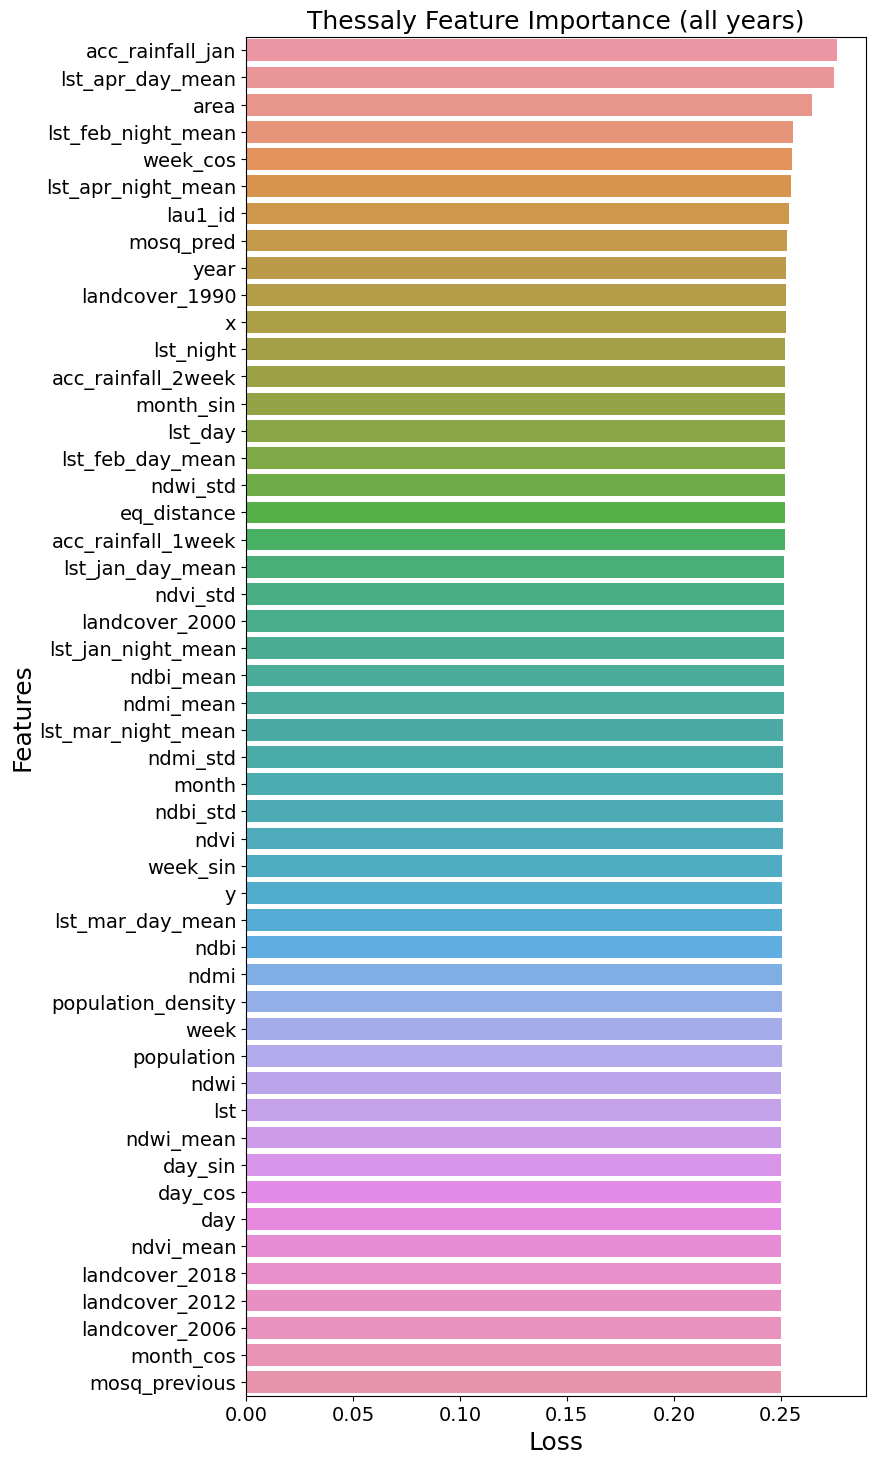

In [16]:
plot_feature_importance(losses, ft_importance['Feature'], x_label = 'Loss', title = f'{NUTS2} Feature Importance (all years)', title_size=18)